# Chapter 2 — Anaconda, Visual Studio Code and Jupyter

This notebook accompanies **Chapter 2 of _Introduction to Image Processing with Python_**.

Its purpose is to verify that the development environment used throughout the book is configured correctly.

The notebook assumes that:

- Anaconda Distribution is installed;
- the `image-processing-python` conda environment has been created;
- Visual Studio Code is installed;
- the Microsoft Python and Jupyter extensions are installed; and
- this notebook has been opened using the `image-processing-python` kernel.

Unlike later notebooks, this notebook is primarily diagnostic. Its job is to confirm that the correct interpreter and scientific Python packages are available.


## Learning objectives

By the end of this notebook, you should be able to:

- identify the Python interpreter used by the notebook;
- identify the active conda environment;
- inspect the installed versions of the principal packages;
- confirm that NumPy, Matplotlib and Pillow import successfully;
- verify that Matplotlib can display an image;
- check that NumPy is using the expected numerical data types; and
- recognise when Visual Studio Code and Jupyter are using the wrong environment.


## 1. Create the conda environment

The project environment is defined by the `environment.yml` file at the root of the repository.

From a terminal opened in the repository root:

```bash
conda env create --file environment.yml
```

Activate it with:

```bash
conda activate image-processing-python
```

If the environment already exists and `environment.yml` has changed, update it with:

```bash
conda env update --file environment.yml --prune
```

The `--prune` option removes packages that are no longer part of the environment definition.


## 2. Select the interpreter in Visual Studio Code

Open the Command Palette and choose:

```text
Python: Select Interpreter
```

Select the interpreter belonging to:

```text
image-processing-python
```

Then open this notebook and select the same environment as the notebook kernel.

The interpreter selected for ordinary Python files and the kernel selected for Jupyter notebooks should both refer to the same conda environment.


## 3. Check the Python interpreter


In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)


Python executable:
/home/robert/miniconda3/envs/image-processing-python/bin/python

Python version:
3.13.15 | packaged by Anaconda, Inc. | (main, Aug 14 2026, 17:26:23) [GCC 14.3.0]


The path printed by `sys.executable` should point into the `image-processing-python` conda environment.

If it points to the Anaconda `base` environment or to a system Python installation, select the interpreter/kernel again before continuing.


## 4. Check the active conda environment


In [2]:
import os

conda_env = os.environ.get("CONDA_DEFAULT_ENV")
conda_prefix = os.environ.get("CONDA_PREFIX")

print(f"CONDA_DEFAULT_ENV: {conda_env}")
print(f"CONDA_PREFIX:      {conda_prefix}")


CONDA_DEFAULT_ENV: image-processing-python
CONDA_PREFIX:      /home/robert/miniconda3/envs/image-processing-python


When the notebook is running through the intended conda environment, `CONDA_DEFAULT_ENV` will normally be:

```text
image-processing-python
```

The exact behaviour can vary slightly depending on how Jupyter was launched, so `sys.executable` remains the most important check.


## 5. Check the installed package versions


In [3]:
from importlib.metadata import PackageNotFoundError, version

packages = [
    "numpy",
    "matplotlib",
    "pillow",
    "jupyterlab",
    "ipykernel",
    "pytest",
]

for package in packages:
    try:
        print(f"{package:12} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:12} NOT INSTALLED")


numpy        2.5.1
matplotlib   3.11.0
pillow       12.3.0
jupyterlab   4.6.2
ipykernel    7.3.0
pytest       9.0.3


Every package listed above should have a version number.

If one is reported as `NOT INSTALLED`, first confirm that the notebook is using the correct environment. If it is, update the environment from `environment.yml`.


## 6. Import the principal scientific packages


In [4]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import PIL
from PIL import Image

print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Pillow:     {PIL.__version__}")


NumPy:      2.5.1
Matplotlib: 3.11.0
Pillow:     12.3.0


If this cell completes without an exception, the main packages needed for the opening chapters are available.


## 7. Confirm NumPy array behaviour


In [5]:
image = np.array([
    [0,   0,  40, 40],
    [0,  60, 120, 40],
    [20, 100, 220, 80],
    [0,  40,  80,  0],
], dtype=np.uint8)

print(image)
print()
print(f"Shape:      {image.shape}")
print(f"Dimensions: {image.ndim}")
print(f"Data type:  {image.dtype}")
print(f"Pixels:     {image.size}")
print(f"Data bytes: {image.nbytes}")


[[  0   0  40  40]
 [  0  60 120  40]
 [ 20 100 220  80]
 [  0  40  80   0]]

Shape:      (4, 4)
Dimensions: 2
Data type:  uint8
Pixels:     16
Data bytes: 16


This is the same small greyscale image used in Chapter 1.

The expected results are:

- shape: `(4, 4)`;
- dimensions: `2`;
- data type: `uint8`;
- pixels: `16`; and
- raw pixel data: `16` bytes.


## 8. Test Matplotlib image display


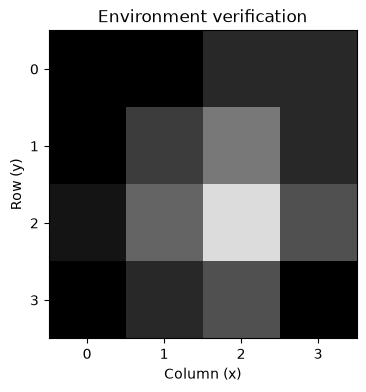

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.imshow(
    image,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)

ax.set_title("Environment verification")
ax.set_xlabel("Column (x)")
ax.set_ylabel("Row (y)")
ax.set_xticks(range(image.shape[1]))
ax.set_yticks(range(image.shape[0]))

plt.show()


A small greyscale image should appear directly below the cell.

If no figure appears, first check that the cell completed without an exception and that the notebook is running with the expected Jupyter kernel.


## 9. Test Pillow


In [7]:
pil_image = Image.fromarray(image)

print(f"Image mode: {pil_image.mode}")
print(f"Image size: {pil_image.size}")


Image mode: L
Image size: (4, 4)


For the example array, Pillow should report:

```text
Image mode: L
Image size: (4, 4)
```

Mode `L` represents an 8-bit greyscale image.


## 10. Verify integer range handling


In [8]:
print(f"np.uint8 minimum: {np.iinfo(np.uint8).min}")
print(f"np.uint8 maximum: {np.iinfo(np.uint8).max}")


np.uint8 minimum: 0
np.uint8 maximum: 255


The expected range is:

\[
0 \leq p \leq 255
\]

where \(p\) is an unsigned 8-bit pixel value.

This range will be important throughout the point-processing and filtering chapters.


## 11. Test a wider intermediate type


In [9]:
pixel = np.uint8(250)
increase = 20

intermediate = np.int16(pixel) + increase
clipped = np.clip(intermediate, 0, 255)
result = np.uint8(clipped)

print(f"Original:     {pixel}")
print(f"Intermediate: {intermediate}")
print(f"Clipped:      {clipped}")
print(f"Result:       {result}")


Original:     250
Intermediate: 270
Clipped:      255
Result:       255


This verifies one of the numerical practices used throughout the book: perform arithmetic in a sufficiently wide type, explicitly handle the permitted range, then convert to the required image type.


## 12. Check the notebook kernel


In [10]:
from pathlib import Path

python_path = Path(sys.executable)

print(f"Kernel Python: {python_path}")
print(f"Environment:   {os.environ.get('CONDA_DEFAULT_ENV', 'not reported')}")


Kernel Python: /home/robert/miniconda3/envs/image-processing-python/bin/python
Environment:   image-processing-python


If this path does not belong to the intended environment:

1. click the kernel selector in the upper-right corner of the notebook editor;
2. choose **Select Another Kernel** if necessary;
3. select **Python Environments**; and
4. choose `image-processing-python`.

Then restart the notebook kernel and run the notebook again from the beginning.


## 13. Repository structure

The working repository is organised around three complementary components:

```text
introduction-to-image-processing-with-python/
|
|-- environment.yml
|
|-- book/
|   |-- main.tex
|   |-- preamble.tex
|   |-- references.bib
|   `-- ...
|
|-- notebooks/
|   |-- 01-introduction.ipynb
|   |-- 02-development-environment.ipynb
|   `-- ...
|
`-- project/
    |-- pyproject.toml
    |-- src/
    |   `-- pyimage/
    `-- tests/
```

The roles are deliberately separated:

- `book/` contains the publication manuscript;
- `notebooks/` contains executable chapter companions; and
- `project/` contains the reusable Python package and automated tests.


## 14. Notebook execution discipline

A notebook can appear to work while depending on variables created by cells run earlier in an unusual order.

Before considering a notebook complete:

1. save it;
2. restart the kernel;
3. run all cells from the beginning;
4. confirm that no unexpected exceptions occur; and
5. check that all figures and numerical outputs are regenerated.

In Visual Studio Code, use **Restart** followed by **Run All**.


## 15. Environment verification summary


In [11]:
checks = {
    "Python executable available": bool(sys.executable),
    "NumPy imported": "np" in globals(),
    "Matplotlib imported": "matplotlib" in globals(),
    "Pillow imported": "PIL" in globals(),
    "Array dtype is uint8": image.dtype == np.uint8,
    "Array shape is 4x4": image.shape == (4, 4),
}

for description, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"{status:4}  {description}")


PASS  Python executable available
PASS  NumPy imported
PASS  Matplotlib imported
PASS  Pillow imported
PASS  Array dtype is uint8
PASS  Array shape is 4x4


## 16. Final checklist

Before continuing to Chapter 3, confirm that:

- [ ] Anaconda Distribution is installed.
- [ ] `conda` works from a terminal.
- [ ] the `image-processing-python` environment exists.
- [ ] Visual Studio Code has the Python extension installed.
- [ ] Visual Studio Code has the Jupyter extension installed.
- [ ] the selected Python interpreter belongs to `image-processing-python`.
- [ ] this notebook is using the same environment as its kernel.
- [ ] NumPy imports successfully.
- [ ] Matplotlib imports successfully.
- [ ] Pillow imports successfully.
- [ ] the test image is displayed correctly.
- [ ] `environment.yml` is stored at the repository root.
- [ ] this notebook runs successfully after restarting the kernel.


## 17. Summary

This notebook verifies the development environment used throughout the project.

Anaconda and conda provide the Python environment and package management. Visual Studio Code provides the common workspace for the LaTeX manuscript, Jupyter notebooks, Python package and tests. The notebook kernel and the interpreter selected by Visual Studio Code should both point to the same `image-processing-python` environment.

The `environment.yml` file provides the reproducible description of the project's initial dependencies.

The next notebook will accompany the chapter covering the Python language features most relevant to implementing image-processing algorithms.


## References

The publication references for this chapter are maintained in the book's master `references.bib` file. The principal sources are the official documentation for Anaconda Distribution, conda environments, Visual Studio Code's Python support and Visual Studio Code's Jupyter support.
